# Book Recommender Project

#### Personalized book suggestions using data, NLP, and Streamlit

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).
* Years: 1975-2024

Books API from [openlibrary](https://openlibrary.org/developers/api). 
* Years: 1900-1975

Developed by: Bryan Calderon

Extracting the 10 most popular books per year!

## **PCA and Clustering**

* Importing libraries

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Feature Engeniering
* Loading final dataset
* Enconding and preparing variables and saving for modeling and clustering

In [3]:
df_cluster = pd.read_csv("../data/join_API_Goodreads.csv")

In [4]:
# Prepare the genres column
df_cluster["genres"] = df_cluster["genres"].fillna("").astype(str)

df_cluster["genres_list"] = (
    df_cluster["genres"]
    .str.lower()
    .str.split(","))

df_cluster["genres_list"] = df_cluster["genres_list"].apply(
    lambda genre_list: [
        genre.strip() 
        for genre in genre_list 
        if genre.strip() != ""])

In [5]:
# List of generic genres
generic_genres = [
    "fiction",
    "general",
    "audiobook",
    "book club"]

In [6]:
# Creating a column without genres categories that are generic
df_cluster["genres_list_clean"] = df_cluster["genres_list"].apply(
    lambda genre_list: [
        genre 
        for genre in genre_list 
        if genre not in generic_genres])

df_cluster[["title", "genres_list", "genres_list_clean"]].head()

,title,genres_list,genres_list_clean
0,The Hound of the Baskervilles,"[crime novel, english civil war, mires, tors, ...","[crime novel, english civil war, mires, tors, ..."
1,The Classic Tale of the Velveteen Rabbit,"[toys, fiction, children's fiction, toys, fict...","[toys, children's fiction, toys, gift books, a..."
2,No country for old men,"[fiction, drug traffic, sheriffs, treasure-tro...","[drug traffic, sheriffs, treasure-trove, treas..."
3,The Prophet,"[poetry, classics, literature & fiction, relig...","[poetry, classics, literature & fiction, relig..."
4,The Railway Children,"[brothers and sisters, children's stories, cla...","[brothers and sisters, children's stories, cla..."


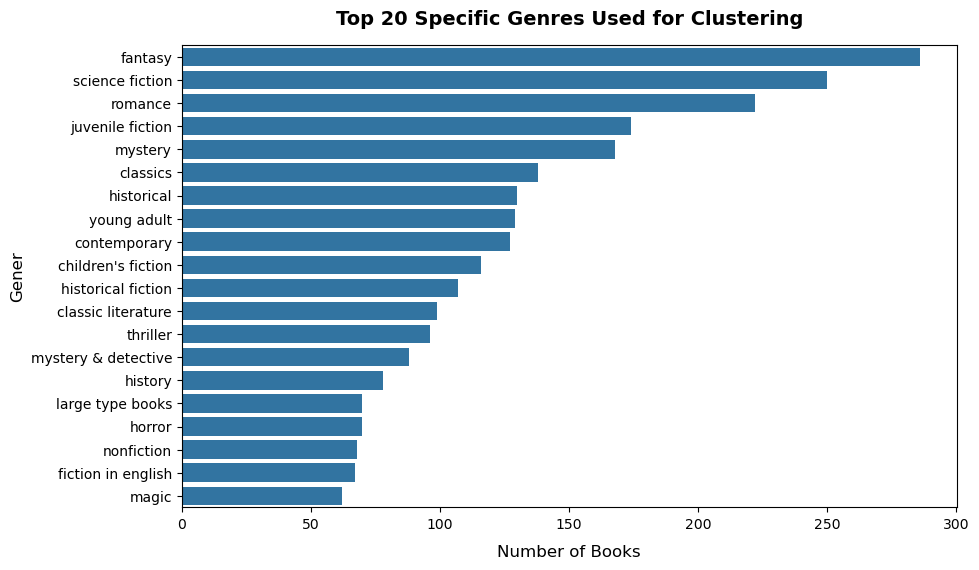

In [7]:
# This is to have a better overview #
top_genres_counts = (
    df_cluster["genres_list_clean"]
    .explode()
    .value_counts()
    .head(20)
    .reset_index())

top_genres_counts.columns = ["genre", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_genres_counts,
    x="count",
    y="genre")

plt.title("Top 20 Specific Genres Used for Clustering", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Books", fontsize=12, labelpad=10)
plt.ylabel("Gener", fontsize=12)
plt.show()

In [8]:
top_20_genres = (
    df_cluster["genres_list_clean"]
    .explode()
    .value_counts()
    .head(20)
    .index
    .tolist())

In [9]:
for genre in top_20_genres:
    clean_column_name = (
        "genre_" 
        + genre
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("'", "")
        .replace(".", "")
        .replace(",", ""))
    
    df_cluster[clean_column_name] = df_cluster["genres_list_clean"].apply(
        lambda genre_list: 1 if genre in genre_list else 0)

In [10]:
genre_features = [col for col in df_cluster.columns if col.startswith("genre_")]
df_cluster[["title"] + genre_features].head()

,title,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,genre_classics,genre_historical,genre_young_adult,genre_contemporary,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,The Hound of the Baskervilles,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,The Classic Tale of the Velveteen Rabbit,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,No country for old men,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Prophet,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,The Railway Children,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


### **Building the final feature matrix**

In [11]:
numeric_features = [
    "average_rating",
    "ratings_count",
    "reviews_count",
    "pages",
    "source_year"]

features = numeric_features + genre_features
X = df_cluster[features]
X.head()

,average_rating,ratings_count,reviews_count,pages,source_year,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,4.016667,60,0,375,1900,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,4.125000,40,0,375,1900,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,4.111111,36,0,375,1900,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.321429,56,0,375,1900,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.965517,29,0,375,1900,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0,0


In [12]:
# Scaling the features / Normalizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.01692801, -0.45143013, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.27270154, -0.45145238, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.23556914, -0.45145683, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       ...,
       [-0.35557373,  0.75540562,  1.58345514, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.41974469,  1.08243035,  2.98427962, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 1.51588453,  1.46027141,  3.10784981, ..., -0.24201281,
        -0.24012332, -0.22255407]], shape=(1229, 25))

#### **Elbow method**

In [13]:
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

inertias

[27248.399625537917,
 25546.745321233102,
 23814.559222223863,
 22215.154402115306,
 20773.679767194008,
 19923.941618829245,
 18591.908339044963,
 17452.558634387235,
 16926.777452844173]

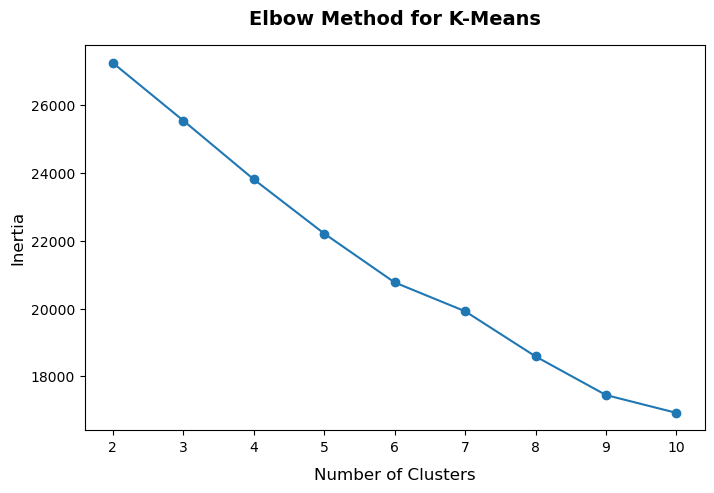

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")

plt.title("Elbow Method for K-Means", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Clusters", fontsize=12, labelpad=10)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(K_range)
plt.show()

NOTE: From this elbow plot, there is no very sharp elbow. The inertia decreases smoothly from k=2 to k=10.

THEREFORE: I choose to continue with k=6 for optimal model selection.

#### **Silhouette score**

In [15]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.16479860232311858,
 0.10074917988470652,
 0.14708451624915622,
 0.14401422392649518,
 0.17100970201243387,
 0.18157526148841546,
 0.20958862581594426,
 0.2071749137950776,
 0.2250233985352423]

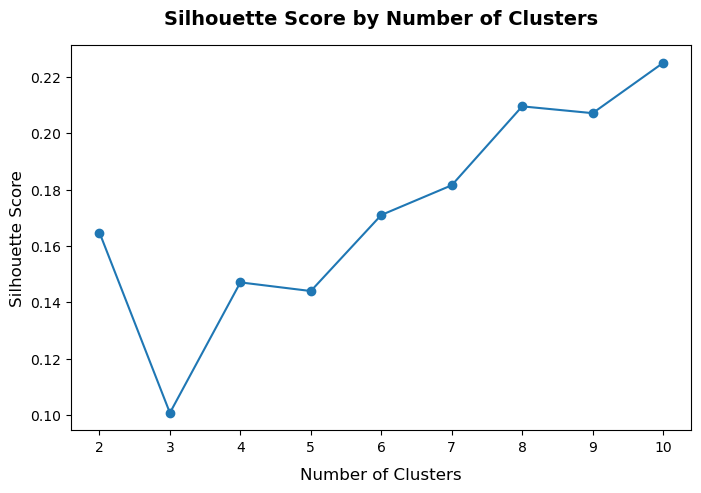

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")

plt.title("Silhouette Score by Number of Clusters", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Clusters", fontsize=12, labelpad=10)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(K_range)
plt.show()

The final selection is stil k=6

#### **K MEANS modeling with 6 clusters**

In [18]:
kmeans_final = KMeans(
    n_clusters=6,         # The best is 6
    random_state=42,
    n_init=10)

df_cluster["cluster"] = kmeans_final.fit_predict(X_scaled)

In [19]:
df_cluster["cluster"].value_counts().sort_index()

cluster
0    119
1    545
2     94
3    200
4    203
5     68
Name: count, dtype: int64

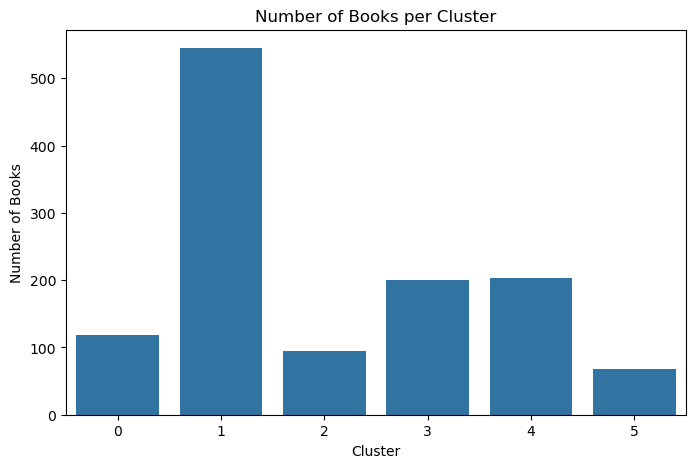

In [20]:
cluster_counts = (
    df_cluster["cluster"]
    .value_counts()
    .sort_index()
    .reset_index())

cluster_counts.columns = ["cluster", "book_count"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_counts,
    x="cluster",
    y="book_count")

plt.title("Number of Books per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Books")
plt.show()

In [22]:
cluster_summary = (
    df_cluster
    .groupby("cluster")
    .agg(
        book_count=("title", "count"),
        avg_rating=("average_rating", "mean"),
        avg_ratings_count=("ratings_count", "mean"),
        avg_reviews_count=("reviews_count", "mean"),
        avg_pages=("pages", "mean"),
        avg_year=("source_year", "mean"))
    .reset_index())

cluster_summary.round(2)

,cluster,book_count,avg_rating,avg_ratings_count,avg_reviews_count,avg_pages,avg_year
0,0,119,4.08,407325.31,22486.13,434.63,1966.02
1,1,545,3.97,45284.04,2381.59,373.16,1945.05
2,2,94,4.05,865934.23,50450.03,410.74,1994.06
3,3,200,4.00,30.25,0.00,375.00,1936.13
4,4,203,4.09,1512879.80,88165.97,415.00,2006.29
5,5,68,4.16,543029.84,25347.87,366.79,1994.79


The K-Means model grouped the books into six clusters based on numerical characteristics and encoded genre information. Cluster 1 is the largest group, suggesting that many books share a common general profile. Smaller clusters represent more specific book profiles. Cluster 5 has the highest average rating, while Cluster 1 has the lowest average rating among the clusters.

* Gender cluster / Summary

In [21]:
genre_cluster_summary = (
    df_cluster
    .groupby("cluster")[genre_features]
    .mean()
    .reset_index())

genre_cluster_summary

,cluster,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,genre_classics,genre_historical,genre_young_adult,genre_contemporary,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,0,0.134454,0.008403,0.420168,0.008403,0.075630,0.327731,0.857143,0.042017,0.058824,...,0.605042,0.075630,0.008403,0.008403,0.184874,0.058824,0.016807,0.0,0.016807,0.008403
1,1,0.126606,0.233028,0.036697,0.003670,0.113761,0.080734,0.001835,0.003670,0.023853,...,0.027523,0.117431,0.005505,0.121101,0.029358,0.106422,0.045872,0.0,0.115596,0.025688
2,2,0.287234,0.138298,0.031915,0.000000,0.787234,0.159574,0.000000,0.074468,0.138298,...,0.063830,0.021277,0.968085,0.000000,0.010638,0.000000,0.404255,0.0,0.000000,0.000000
3,3,0.215000,0.050000,0.005000,0.855000,0.035000,0.010000,0.015000,0.000000,0.000000,...,0.020000,0.120000,0.000000,0.005000,0.065000,0.025000,0.000000,0.0,0.010000,0.100000
4,4,0.566502,0.123153,0.640394,0.000000,0.068966,0.147783,0.000000,0.566502,0.458128,...,0.049261,0.000000,0.004926,0.000000,0.000000,0.000000,0.009852,0.0,0.000000,0.113300
5,5,0.000000,0.000000,0.029412,0.000000,0.029412,0.117647,0.117647,0.000000,0.014706,...,0.000000,0.000000,0.000000,0.000000,0.338235,0.000000,0.000000,1.0,0.000000,0.000000


In [22]:
for cluster in sorted(df_cluster["cluster"].unique()):
    print(f"\nCluster {cluster} - Top Genres")
    
    cluster_genres = (genre_cluster_summary[genre_cluster_summary["cluster"] == cluster]
        .drop(columns="cluster")
        .T
        .reset_index())
    
    cluster_genres.columns = ["genre", "share"]
    cluster_genres = cluster_genres.sort_values("share", ascending=False).head(5)
    
    display(cluster_genres)


Cluster 0 - Top Genres


,genre,share
6,genre_historical,0.857143
10,genre_historical_fiction,0.605042
2,genre_romance,0.420168
5,genre_classics,0.327731
14,genre_history,0.184874



Cluster 1 - Top Genres


,genre,share
1,genre_science_fiction,0.233028
0,genre_fantasy,0.126606
13,genre_mystery_and_detective,0.121101
11,genre_classic_literature,0.117431
18,genre_fiction_in_english,0.115596



Cluster 2 - Top Genres


...

,genre,share
3,genre_juvenile_fiction,0.855
9,genre_childrens_fiction,0.580
0,genre_fantasy,0.215
11,genre_classic_literature,0.120
19,genre_magic,0.100



Cluster 4 - Top Genres


,genre,share
2,genre_romance,0.640394
0,genre_fantasy,0.566502
7,genre_young_adult,0.566502
8,genre_contemporary,0.458128
5,genre_classics,0.147783



Cluster 5 - Top Genres


,genre,share
17,genre_nonfiction,1.000000
14,genre_history,0.338235
6,genre_historical,0.117647
5,genre_classics,0.117647
4,genre_mystery,0.029412


In [23]:
# With such information we can define better the clustering names like for example#
cluster_labels = {
    0: "Historical & classic fiction",
    1: "General genre fiction",
    2: "Thriller, mystery & horror",
    3: "Children’s & juvenile fantasy",
    4: "Romance, fantasy & young adult",
    5: "Nonfiction & history"}

df_cluster["cluster_label"] = df_cluster["cluster"].map(cluster_labels)

The clusters represent different book profiles, including historical and classic fiction, general genre fiction, thriller/mystery/horror, children’s and juvenile fantasy, romance/fantasy/young adult, and nonfiction/history.

In [26]:
cluster_summary_labeled = (
    df_cluster
    .groupby(["cluster", "cluster_label"])
    .agg(
        book_count=("title", "count"),
        avg_rating=("average_rating", "mean"),
        avg_ratings_count=("ratings_count", "mean"),
        avg_reviews_count=("reviews_count", "mean"),
        avg_pages=("pages", "mean"),
        avg_year=("source_year", "mean"))
    .reset_index())

cluster_summary_labeled.round(2)

,cluster,cluster_label,book_count,avg_rating,avg_ratings_count,avg_reviews_count,avg_pages,avg_year
0,0,Historical & classic fiction,119,4.08,407325.31,22486.13,434.63,1966.02
1,1,General genre fiction,545,3.97,45284.04,2381.59,373.16,1945.05
2,2,"Thriller, mystery & horror",94,4.05,865934.23,50450.03,410.74,1994.06
3,3,Children’s & juvenile fantasy,200,4.00,30.25,0.00,375.00,1936.13
4,4,"Romance, fantasy & young adult",203,4.09,1512879.80,88165.97,415.00,2006.29
5,5,Nonfiction & history,68,4.16,543029.84,25347.87,366.79,1994.79


## **PCA analysis**

In [24]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_cluster["pca_1"] = pca_result[:, 0]
df_cluster["pca_2"] = pca_result[:, 1]

In [25]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 15.09%
PC2 explained variance: 7.91%
Total explained variance: 22.99%


NOTE: It is recommended to try the PCA with more dimnesions to see if the variance are in other ones!

* Graphs

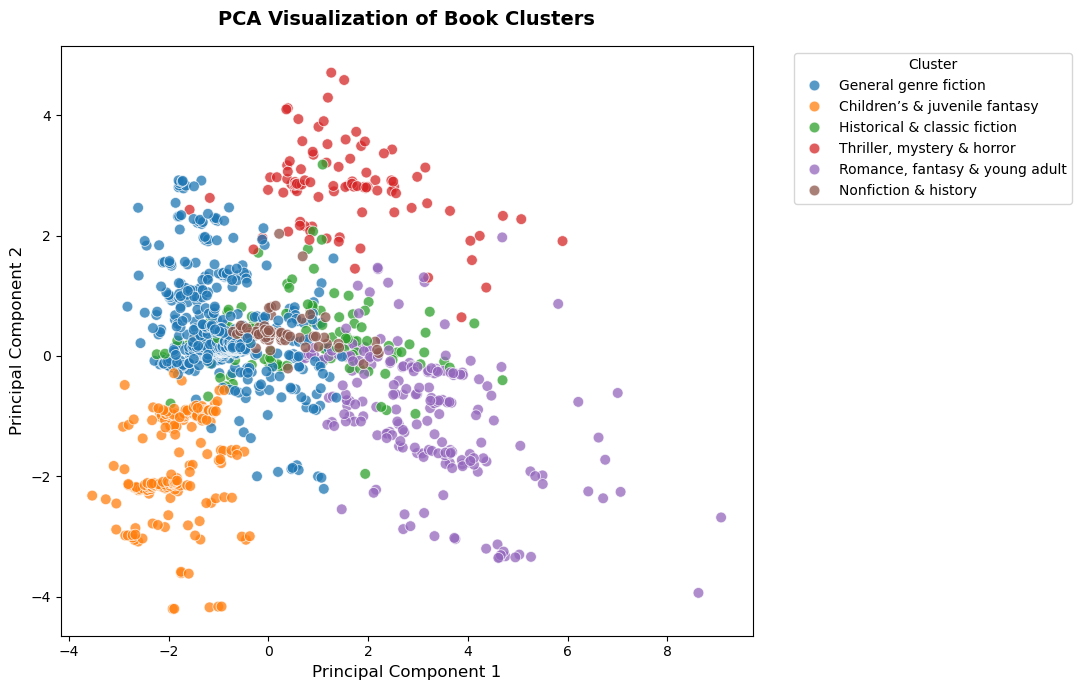

In [29]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="cluster_label",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization of Book Clusters", fontsize=14, pad=15, weight="bold")
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Some genre groups clearly occupy different regions of the PCA space.

The PCA plot provides a useful visual approximation of the clusters, but it does not represent all the information used by K-Means.

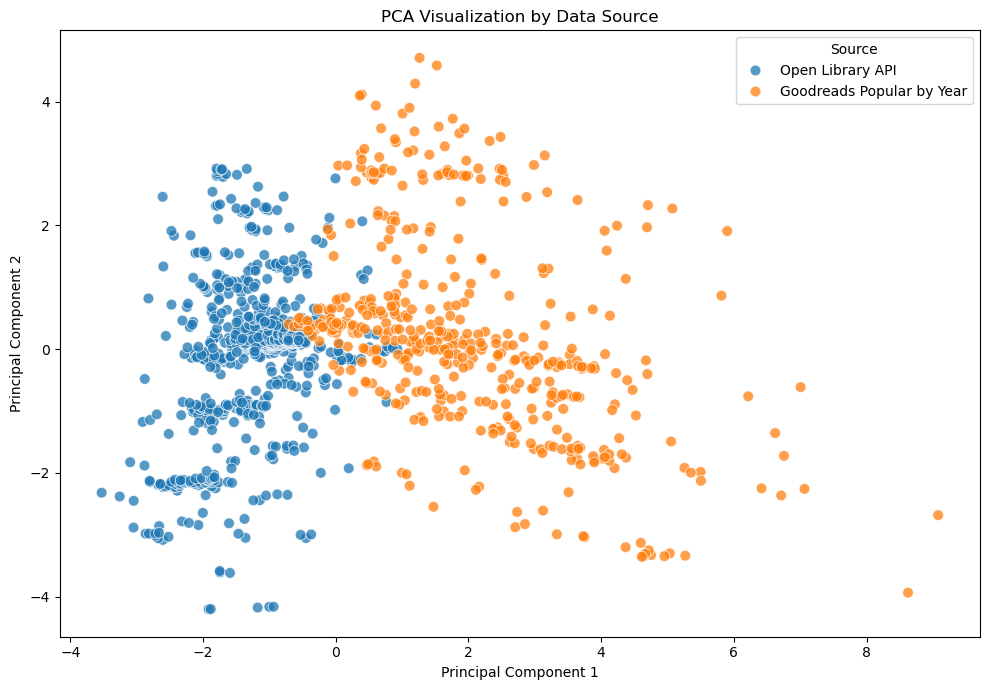

In [30]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="source",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization by Data Source")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

PC1 partly separates books by data source, which reflects differences in publication years, ratings/reviews availability, and metadata structure.

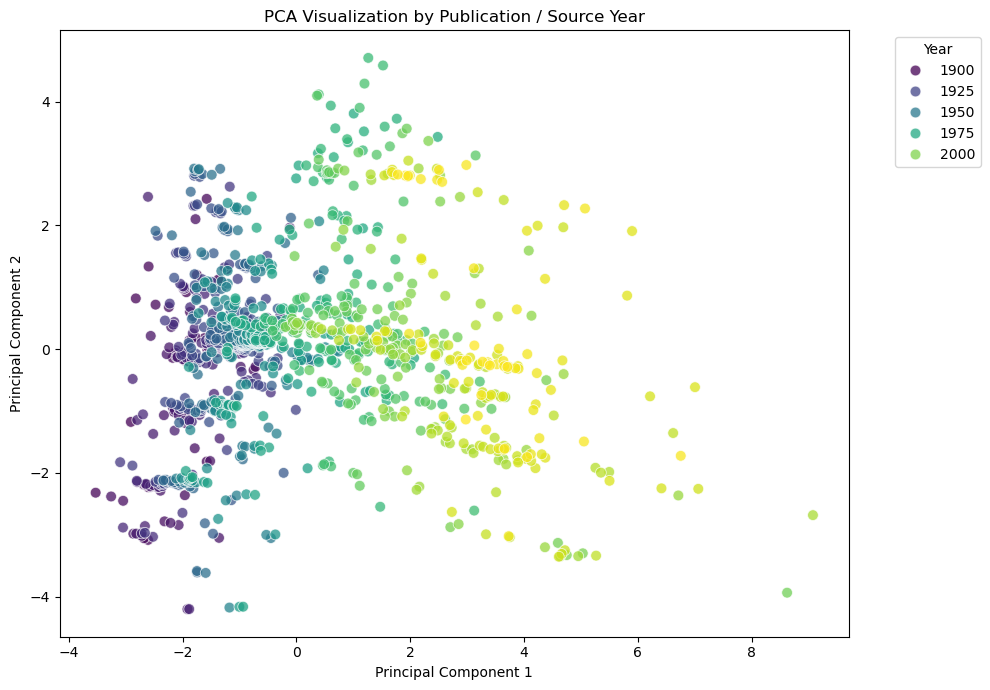

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="source_year",
    palette="viridis",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization by Publication / Source Year")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

PC1 captures a historical/popularity dimension, separating older books from newer and more digitally reviewed books.

In [32]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features)

pca_loadings.head()

,PC1,PC2
average_rating,0.125314,-0.038197
ratings_count,0.409020,-0.088788
reviews_count,0.420630,-0.057260
pages,0.100834,-0.070048
source_year,0.435070,0.061996


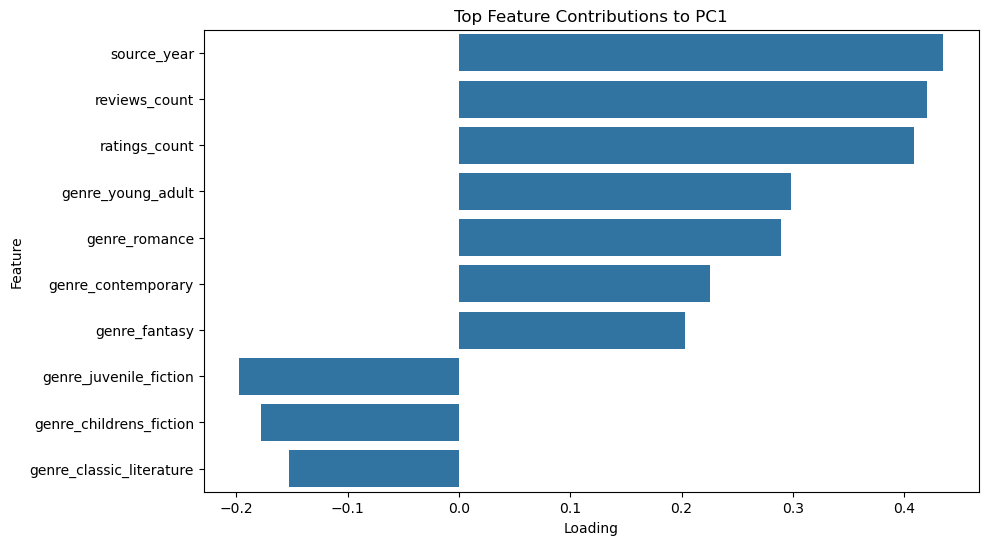

In [33]:
pc1_top = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pca_loadings.loc[pc1_top, "PC1"],
    y=pc1_top)

plt.title("Top Feature Contributions to PC1")
plt.xlabel("Loading")
plt.ylabel("Feature")
plt.show()

PC1 separates newer, highly engaged contemporary/romance/fantasy books from older or more classic/children’s literature.

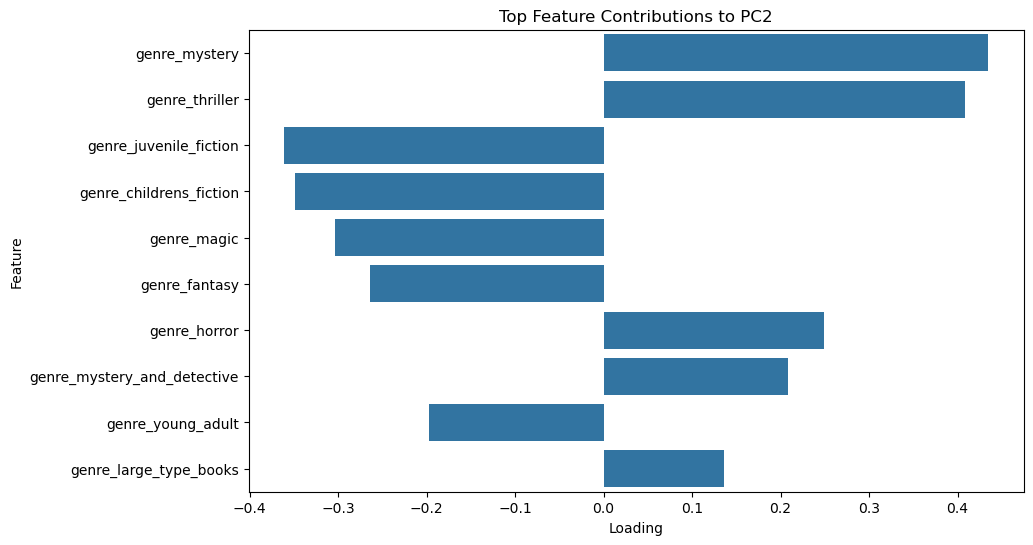

In [34]:
pc2_top = (
    pca_loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pca_loadings.loc[pc2_top, "PC2"],
    y=pc2_top)

plt.title("Top Feature Contributions to PC2")
plt.xlabel("Loading")
plt.ylabel("Feature")
plt.show()

PC2 mainly separates mystery, thriller, and horror books from children’s, juvenile, magical, and fantasy-oriented books.

* Saving clustered data with PCA

In [35]:
df_cluster.to_csv("../data/Books_Clusters_PCA.csv", index=False)